In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Defining constants

In [2]:
N_TRIALS = 2000
N_ARMS = 16
N_FEATURES = 5
BEST_ARMS = [3, 7, 9, 15]

Problem settings

In [3]:
# Generating the context data for every for every arm for every trial (they are all random)
def make_design_matrix(n_trials, n_arms, n_features):
    """
    Generate context vectors for all arms for each of the trial
    Parameters:
    -----------
        n_trials: number of trials
        n_arms: number of arms per trial
        n_features: number of feature per context vector
    Returns:
    ----------
        A matrix of size n_trials x n_arms x n_features
    """
    available_arms = np.arange(n_arms)
    X = np.array([[np.random.uniform(0, 1, size = n_features) for _ in np.arange(n_arms)] for _ in np.arange(n_trials)])
#     X = np.array([[arm/(np.sqrt(arm.dot(arm))) for arm in trial] for trial in orig_x])
    # normalize it too.
    
    return X

In [4]:
# Generating a theoretical true theta so we can have things to compare with. I.e., will compare the oracles vs. the rewards from the selected arms
def make_theta(n_arms, n_features, best_arms, bias = 1):
    """
    Generate true theta for testing purpose.
    Parameters:
    ----------
        n_arms: number of arms
        n_features: number of features for the context vector
        best_arms: arms in which we should give some bias values (for good)
        bias: value to be added to the best arms
    Returns:
    ----------
        A matrix of size n_arms x n_features, each value is a random value with mean = 0 and standard deviation of 1/4. However, for the best arms, we will add the bias
    """
    true_theta = np.array([np.random.normal(size=n_features, scale=1.0/4.0) for _ in range(n_arms)])
    true_theta[best_arms] += bias
    return true_theta

In [5]:
def generate_reward(arm, x, theta, scale_noise = 1.0/10.0):
    """
    Generate reward for an arm given a context
    Parameters:
    ----------
        arm: this is the arm index (0 to number of arms - 1)
        x: is the context that we are observing for the arm index (arm)
        theta: is the theta (true or predicted) that are are using to estimate the reward for each arm
        scale_noise: we may need to add some random noise (mean 0 and standard deviation as scale_noise)
    Returns:
    ----------
        The estimated score for the arm (with the arm index and the context observed corresponding to the given theta)
    """
    signal = theta[arm].dot(x)
    noise = np.random.normal(scale=scale_noise)
    return signal + noise

In [6]:
def make_regret(payoffs, oracles):
    """
    Generate the cummulative regret over time.
    Parameters:
    -----------
        payoffs: an array of T payoffs (for T number of trials)
        oracles: an array of best values for T trials (oracles)
    Returns:
        Array of the cumulative sum over time (of size T = number of trials)
    """
    return np.cumsum(oracles - payoffs)

In [7]:
X = make_design_matrix(n_trials=N_TRIALS, n_arms=N_ARMS, n_features=N_FEATURES)
true_theta = make_theta(n_arms=N_ARMS, n_features=N_FEATURES, best_arms=BEST_ARMS)

Visualization of average payoff per arm

In [8]:
payoffs = [[generate_reward(arm=arm, x=X[t, arm], theta=true_theta) for arm in np.arange(N_ARMS)] for t in np.arange(N_TRIALS)]
ave_rewards = np.mean(payoffs, axis=0)

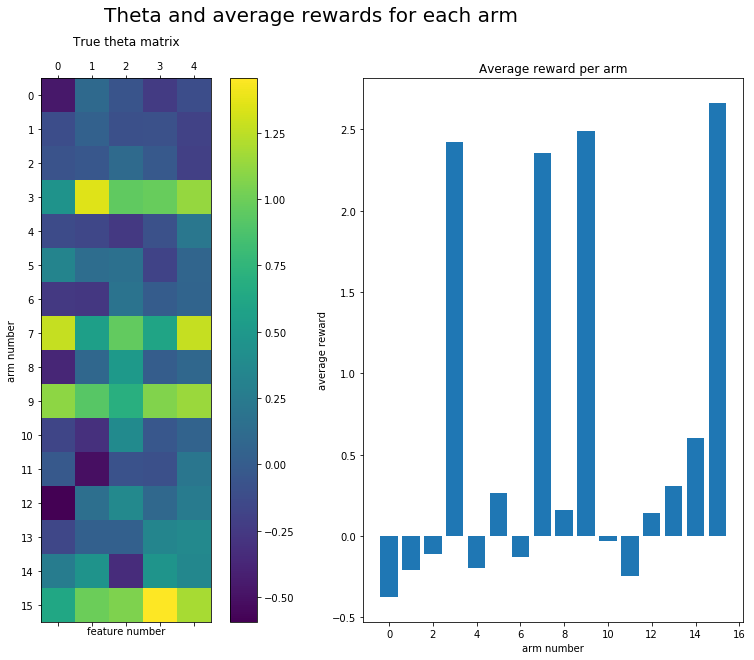

In [9]:
f, (theta_fig, avg_reward_fig) = plt.subplots(1, 2, figsize=(15, 10))
f.suptitle("Theta and average rewards for each arm", fontsize=20)
# Visualizing true theta
theta_fig.matshow(true_theta)
f.colorbar(theta_fig.imshow(true_theta), ax = theta_fig)
theta_fig.set_xlabel("feature number")
theta_fig.set_ylabel("arm number")
theta_fig.set_yticks(np.arange(N_ARMS))
theta_fig.set_title("True theta matrix")

# Visualizing avewrage reward
avg_reward_fig.bar(np.arange(N_ARMS), ave_rewards)
avg_reward_fig.set_title("Average reward per arm")
avg_reward_fig.set_xlabel("arm number")
avg_reward_fig.set_ylabel("average reward")
plt.show()


# 1. LINUCB

Learned from: A Contextual-Bandit Approach to Personalized News Article Recommendation (paper from Li et al.)
## Problem formulation

A contextual bandit A proceeds in discrete trials t = 1, 2, 3, ... In trial t
1. The algorithm observes current user $u_t$ and a set $A_t$ of arms (actions). These two made up $x_{t, a}$ for every $a \in A_t$, and is called the $context$.
2. Based on the observed payoffs in previous trials, $A$ chooses an arm $a_t \in A_t$, and receives a payoff $r_{t,a_t}$ whose expectation depends on both the user $u_t$ and the arm $a_t$.
3. $A$ improves arm-selection strategy with the new observation $(x_{t, a_t}, a_t, r_{t, a_t})$.
4. The total T-trial payoff of $A$ is defined as $\sum_{t=1}^{T}r_{t, a_t}$
5. Optimal expected T-trial payoff is defined as $E[\sum_{t=1}^Tr_{t, a_t^*}]$, where $a_t^*$ is the arm with maximum expected payoff at trial $t$.
6. The goal for $A$ is to maximize payoff or minimize the regret, which is defined as:
\begin{equation}
    R_A(T) = E[\sum_{t=1}^Tr_{t, a_t^*}] - E[\sum_{t=1}^Tr_{t, a_t}]
\end{equation}

## The algorithm
Assume that the payoff of an arm $a$ is linear in its d-dimensional feature x_{t, a} with some unknown coefficient vector $\theta_a^*$:
\begin{equation}
E[r_{t, a} | x_{t, a}] = x_{t, a}^T\theta_a^*
\end{equation}

Let $D_a$ be a design matrix of dimension $m\times d$ at trial $t$, $m$ is the training inputs (e.g., m contexts that are observed previously for article a), and $c_a \in R^m$ be the corresponding response vector (e.g., the corresponding $m$ click/no-click user feedback). Applying ridge regression to the training data ($D_a$, $b_a$) gives an estimate of the coefficients:

\begin{equation}
\hat\theta_a = (D_a^TD_a + I_d)^{-1}D_a^Tb_a
\end{equation}

It can be proved that, with probability at least $1-\delta$:
\begin{equation}
|x_{t, a}^T\hat\theta_a - E[r_{t, a}|x_{t, a}]| \leq \alpha \sqrt{x_{t, a}^T(D_a^TDa + I_d)^{-1}x_{t, a}}
\end{equation}
for any $\delta>0$ and $x_{t, a} \in R^d$, where $\alpha = \sqrt{ln(2/\delta)/2}$ is a constant.

In other words, the inequality above gives a reasonably tight UCB for the expected payoff of arm a, from which a UCB-type arm-selection strategy can be derived: at each trial t, choose:
\begin{equation}
a_t = arg\,\underset{a\in A_t}{max}(x_{t, a}^T + \alpha\sqrt{x_{t, a}^T A_a^{-1}x_{t, a}})
\end{equation}
where $A_a = D_a^TD_a + I_d$

Also, the expected payoff $x_{t, a}^T\theta_a^*$ can be calculated as $x_{t, a}^TA_a^{-1}$, and then $\sqrt{x_{t, a}^TA_a^{-1}x_{t, a}}$ becomes the standard deviation.

Therefore the upper bound should be:
\begin{equation}
    \hat\theta_{t, a} = A_a^{-1}b_a \\
    p_{t, a} = \hat\theta_{t, a}x_{t, a} + \alpha*\sqrt{x_{t, a}A^{-1}x_{t, a}}
\end{equation}

In [10]:
# Inspired from: https://github.com/etiennekintzler/bandits_algorithm/blob/master/linUCB.ipynb
def lin_ucb(alpha, X, generate_reward, true_theta):
    """
    Simulate the LINUCB algorithm using the generated data X.
    Parameters:
    -----------
        alpha: this is the ::math:`\alpha = \sqrt{ln(2/\sigma)/2}`
        X: is the observed data (contexts for all arms at every trial)
        generate_reward: a function used to generate the reward for an arm given a context and a theta
        true_theta: the true theta used to generate the oracles and compare the losses (regrets)
    """
    # Data storages
    n_trials, n_arms, n_features = X.shape
    arm_choice = np.empty(n_trials) # used to store agent's choices for each trial
    r_payoffs = np.empty(n_trials) # used to store the payoff for each trial (the payoff for the selected arm based on the true_theta)
    theta = np.empty(shape=(n_trials, n_arms, n_features)) # used to store the predicted theta over each trial
    p = np.empty(shape=(n_trials, n_arms)) # used to store predictions for reward of each arm for each trial
    # Lin UCB Objects
    A = np.array([np.diag(np.ones(shape=n_features)) for _ in np.arange(n_arms)]) # A is the matrix defined as :math:A_a = D_a^TD_a + I_d, and for the initialization it is I_d and will be updated after every trial
    b = np.array([np.zeros(shape=n_features) for _ in np.arange(n_arms)]) # b is the matrix defined as response vectors (reward for each feature for each arm at each trial, initialized to zero for all features of all arms at every trial)
    # The algorithm
    for t in range(n_trials):
        # compute the estimates (theta) and prediction (p) for all arms
        for a in range(n_arms):
            inv_A = np.linalg.inv(A[a])
            theta[t, a] = inv_A.dot(b[a]) # estimate theta as from this formula :math:`\hat{\theta}_a = A_a^{-1}b_a`
            p[t, a] = theta[t, a].dot(X[t, a]) + alpha * np.sqrt(X[t, a].dot(inv_A).dot(X[t, a])) # predictions is the expected mean + the confidence upper bound
        # choosing the best arms
        chosen_arm = np.argmax(p[t])
        x_chosen_arm = X[t, chosen_arm]
        r_payoffs[t] = generate_reward(arm=chosen_arm, x = x_chosen_arm, theta=true_theta) # This payoff is for the predicted chosen arm, and but the payoff is based on theoretical theta (true theta)
        arm_choice[t] = chosen_arm
        
        # Update intermediate objects (A and b)
        A[chosen_arm] += np.outer(x_chosen_arm, x_chosen_arm.T)
        b[chosen_arm] += r_payoffs[t]*x_chosen_arm # update the b values for each features corresponding to the pay off and the features of the chosen_arm
    return dict(theta=theta, p=p, arm_choice=arm_choice, r_payoffs = r_payoffs)

In [11]:
# Defining oracle (best payoffs based on the true_theta)
oracles = np.array([np.max([generate_reward(arm=arm, x=X[t, arm], theta=true_theta) for arm in range(N_ARMS)]) for t in range(N_TRIALS)])

In [12]:
len(oracles)

2000

In [13]:
# Define random payoff (see how if we just select an arm randomly, then how is the payoffs going to be)
random_payoffs = np.array([generate_reward(arm=np.random.choice(N_ARMS), x = X[t, np.random.choice(N_ARMS)], theta=true_theta) for t in range(N_TRIALS)])

In [14]:
# calcualte the regret for random policy
random_regrets = make_regret(payoffs=random_payoffs, oracles=oracles)

## Testing for various alpha for LIN UCB

In [15]:
alphas = [0, 1, 2.5, 5, 10, 20]
results_dict = {alpha: lin_ucb(alpha=alpha, X = X, generate_reward=generate_reward, true_theta=true_theta) for alpha in alphas}

## Analyzing regrets, coefficients estimates and chosen arm

In [16]:
def plot_regrets(results, oracles):
    [plt.plot(make_regret(payoffs=x['r_payoffs'], oracles=oracles), label="alpha: " + str(alpha)) for (alpha, x) in results.items()]

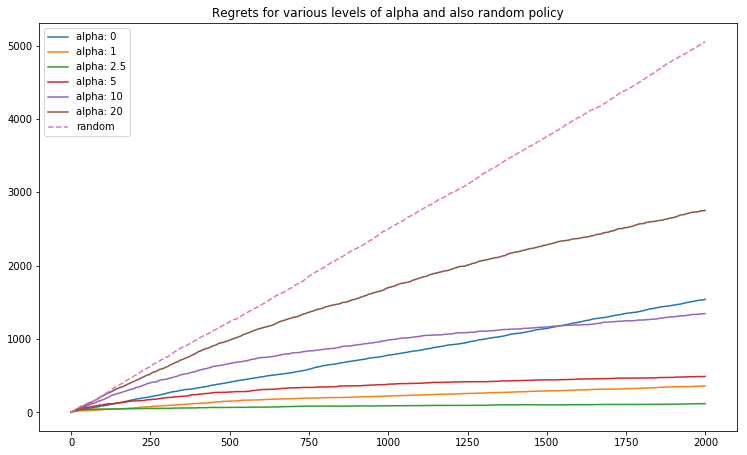

In [17]:
plt.figure(figsize=(12.5, 7.5))
plot_regrets(results_dict, oracles)
# plot also the random one
plt.plot(make_regret(random_payoffs, oracles), label='random', linestyle='--')
plt.legend()
plt.title("Regrets for various levels of alpha and also random policy")
plt.show()

# 2. Thompson Sampling

Learned from: https://gdmarmerola.github.io/ts-for-contextual-bandits/

# The contextual bandit
The contextual bandit is just like MAB problem but now the true expected reward parameter $\theta_k$ depends on external variables. Therefore, we add the notion of context (or state) to support our decision.

Thus, we're going to suppose that the probability of reward is now of the form:
\begin{equation}
    \theta_k(x) = \frac{1}{1+exp(-f(x))}
\end{equation}
where
\begin{equation}
    f(x) = \beta_0 + \beta_1 . x + \epsilon
\end{equation}

and $\epsilon \sim \mathcal{N}(0, \sigma^2)$. In other words, the expected reward parameters for each bandit linearly depends on an external variable $x$ with logistic link.

# The algorithm
Thompson Sampling for Contextual bandits
> Set $B = I_d, \hat\mu=0_d, f = 0_d$
>
> **for all** $t=1, 2, ..., $ **do**
>> Sample $\tilde{\mu}(t)$ from distribution $\mathcal{N}(\hat\mu, v^2B^{-1})$
>>
>> Play arm $a(t) = arg\,max_i b_i(t)^T \tilde{\mu}(t)$, and observe reward $r_t$
>>
>> Updates:
>>>
>>> $B = B + b_{a(t)}(t)b_{a(t)}(t)^T$
>>> 
>>> $f = f + b_{a(t)}(t)r_t$
>>>
>>> $\hat\mu = B^{-1}f$
>>
>**end for**

Where $v = R\sqrt{\frac{24}{\epsilon}d ln(\frac{1}{\delta})}$, with $\epsilon \in (0, 1)$ parameterizes the algorithm.

Followings are the initialized values:
delta $\delta = 0.5$, $R=0.01$, $\epsilon=0.5$

In [18]:
def thompson_sampling(X, true_theta, R=0.01, epsilon=0.5, delta=0.5):
    '''
    Parameters:
    --------------
    delta: float, 0 < delta < 1
        With probability 1 - delta, linear thompson sampling satisfies the theoretical regret bound.
    R: float, R >= 0
        Assume that the residual  :math:`ri(t) - bi(t)^T \hat{\mu}` is R-sub-gaussian. 
        In this case, R^2 represents the variance for residuals of the linear model :math:`bi(t)^T`.
    epsilon: float, 0 < epsilon < 1
        A  parameter  used  by  the  Thompson Sampling algorithm. If the total trials T is known, we can choose epsilon = 1/ln(T).
    '''
    n_trials, n_arms, n_features = X.shape
    r_payoffs = np.zeros(n_trials) # used to store the payoff for each trial (the payoff for the selected arm based on the true_theta)
    v = R * np.sqrt(24 / epsilon * n_features * np.log(1 / delta))
    
    
    # model initialization
    B = np.identity(n_features) 
    mu_hat = np.zeros(shape=(n_features, 1))
    f = np.zeros(shape=(n_features,1))    

    for t in range(n_trials):
        context = X[t]
        mu_tilde = np.random.multivariate_normal(mu_hat.flat, v**2 * np.linalg.inv(B))[..., np.newaxis]
        score_array = context.dot(mu_tilde)
        chosen_arm = np.argmax(score_array)
        context_t = context[chosen_arm]
        reward = generate_reward(arm=chosen_arm, x=context_t, theta=true_theta)
        r_payoffs[t] = reward
        context_t = np.reshape(context_t, (-1, 1))
        B += context_t.dot(context_t.T)
        f += reward*context_t
        mu_hat = np.linalg.inv(B).dot(f)
    return dict(r_payoffs = r_payoffs)

In [19]:
# delta=0.61, r=0.01, epsilon=0.71
R = 0.01
epsilon = 0.5
delta = 0.5
thompson_results = thompson_sampling(X=X, true_theta=true_theta, R = R, epsilon=epsilon, delta = delta)

In [20]:
thompson_results['r_payoffs']

array([ 0.39279706, -0.41589077, -0.33659161, ...,  5.10612778,
        0.93540983,  0.43292279])

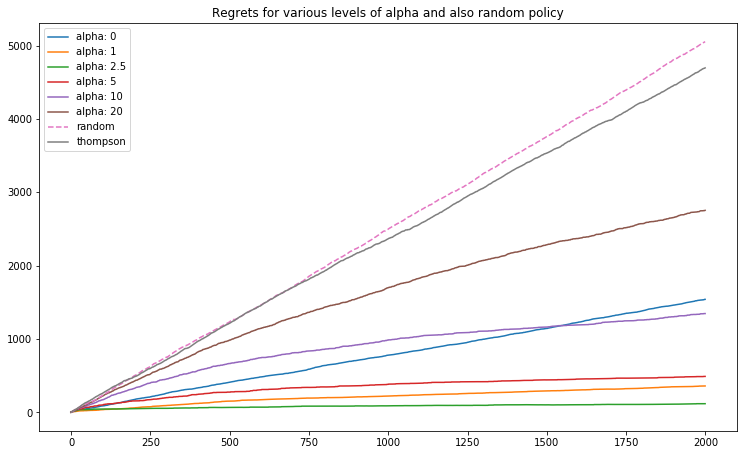

In [21]:
plt.figure(figsize=(12.5, 7.5))
# plot for LinUCB
plot_regrets(results_dict, oracles)
# plot also the random one
plt.plot(make_regret(random_payoffs, oracles), label='random', linestyle='--')
# plot for Thompson
plt.plot(make_regret(thompson_results['r_payoffs'], oracles), label='thompson')
plt.legend()
plt.title("Regrets for various levels of alpha and also random policy")
plt.show()